## Paper

In [1]:
import copy
import importlib
import os
from pathlib import Path
import random
import warnings

from matplotlib import pyplot as plt
from matplotlib import patches as mpl_patches
from matplotlib import font_manager as fm
import numpy as np
import ratinabox
from ratinabox import utils as rutils
import scipy.stats
from tqdm import tqdm

from predhpc import agent, env, plot_fcts, run_manager
from predhpc.experiments import metrics, linear_track
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import ext_util, hyper_util, plot_util, params_util, animate_util, gen_util, learn_util, signal_util

%load_ext autoreload

In [ ]:
%autoreload 2

In [2]:
SEED = 18

In [5]:
def set_font():
    font_dir = Path(os.environ["HOME"], "Documents", "fonts")
    if not Path(font_dir).is_dir():
        print("Font directory not found.")
    font_files = fm.findSystemFonts(fontpaths=str(font_dir))
    for font_file in font_files:
        fm.fontManager.addfont(font_file)
    plt.rcParams["font.family"] = "Arial"

In [6]:
plot_util.stylize_plots_for_notebook()
rcParams = {
    "axes.labelsize"   : "small",
    "axes.linewidth"   : 1,
    "xtick.labelsize"  : "small",
    "xtick.major.size" : 5,
    "xtick.major.width": 1,
    "ytick.labelsize"  : "small",
    "ytick.major.size" : 5,
    "ytick.major.width": 1,
}
plt.rcParams.update(rcParams)
set_font()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "paper"))

ALL_FIGURES = dict()

In [7]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [10]:
def seed_all(seed=None):
    random.seed(seed)
    np.random.seed(seed)

In [90]:
def get_linear_Pyrs(
    speed_mean=params_util.SPEED_MEAN_LINEAR, 
    speed_std=params_util.SPEED_STD, 
    wait_at_end=int(15 / params_util.DT),
    log_BTSP=True
):

    target_position = params_util.get_target_position()
    
    agent_params = params_util.get_agent_params(
        environment="linear",
        target_position=target_position,
        speed_mean=speed_mean,
        speed_std=speed_std,
        wait_at_end=wait_at_end,
    )
    
    Pyr_params = params_util.get_Pyr_params(
        environment="linear",
        log_BTSP=log_BTSP,
    )
    
    Pyrs = run_manager.init_env_objects(
        agent_params=agent_params,
        Pyr_params=Pyr_params,
        environment="linear",
        plot=False,
        )

    return Pyrs

def run_linear(Pyrs=None, max_num_steps=3800, max_time_min=None, **kwargs):
    if Pyrs is None:
        Pyrs = get_linear_Pyrs()

    if max_time_min is not None:
        max_num_steps = int(max_time_min * 60 / Pyrs.Agent.dt)
        
    learner = run_manager.learn_1D_BTSP(
        Pyrs,
        BTSP_on=0,
        max_num_steps=max_num_steps,
        plot=False,
        **kwargs
    )

    return learner

def run_linear_speeds():
    save_path = Path(ratinabox.figure_directory, f"speed_data_{SEED}.npz")

    if save_path.is_file():
        print("Loading data.")
        speed_data = np.load(save_path)

        return speed_data

    speed_means = np.asarray([np.around(speed_mean, 9) for speed_mean in np.linspace(0.05, 0.4, 29)])    
    saved_speeds = [0.15, 0.35]
    
    saved_weights = list()
    widths = list()
    for speed_mean in tqdm(speed_means):
        seed_all(SEED)
        Pyrs = get_linear_Pyrs(speed_mean=speed_mean, speed_std=0, log_BTSP=False, wait_at_end=0)
        learner = run_linear(Pyrs, max_time_min=1.2, no_logs=True)
        FWHM = metrics.compute_PC_FWHM(Pyrs)
        widths.append(FWHM)
        if speed_mean in saved_speeds:
            print(f"Recording weights for {speed_mean} m/s.")
            saved_weights.append(learner.get_recorded_weights()["weights"][:, 0])
    widths = np.asarray(widths)
    saved_weights = np.asarray(saved_weights)

    speed_data = {
        "speed_means": speed_means,
        "widths": np.asarray(widths),
        "saved_speeds": np.asarray(saved_speeds),
        "saved_weights": np.asarray(saved_weights),
    }

    np.savez(save_path, **speed_data)
    print("Data saved.")

    return speed_data

In [97]:
def run_linear_shifts():
    save_path = Path(ratinabox.figure_directory, f"shift_data_{SEED}.npz")

    if save_path.is_file():
        print("Loading data.")
        shift_data = np.load(save_path)

        return shift_data
    
    shifts = np.asarray([np.around(speed_mean, 9) for speed_mean in np.linspace(-3.6, 2.4, 61)])

    seed_all(SEED)
    Pyrs = get_linear_Pyrs(speed_std=0, log_BTSP=False, wait_at_end=0)
    orig_learner = run_linear(Pyrs, max_time_min=1.2, no_logs=True)

    weights = list()
    widths = list()
    for shift in tqdm(shifts):
        seed_all(SEED)
        learner = copy.deepcopy(orig_learner)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning, message="Target position")
            learner.Pyrs.Agent.move_target_position(shift)
        learner = run_linear(learner, max_time_min=1.2, no_logs=True)
        FWHM = metrics.compute_PC_FWHM(Pyrs)
        widths.append(FWHM)
        weights.append(learner.get_recorded_weights()["weights"][:, 0])

    shift_data = {
        "shifts": shifts,
        "widths": np.asarray(widths),
        "weights": np.asarray(weights)
    }

    np.savez(save_path, **speed_data)
    print("Data saved.")
        
    return shift_data

In [13]:
def format_PF_xaxis(sub_ax):
    sub_ax.set_xlim([0, 6])
    sub_ax.set_xticks([0, 6])
    plot_util.expand_ticks(sub_ax, axis="x", num_ticks=7, alternating=True, round_dec=0)

### Fig. 1

In [14]:
seed_all(SEED)
Pyrs = get_linear_Pyrs()
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)

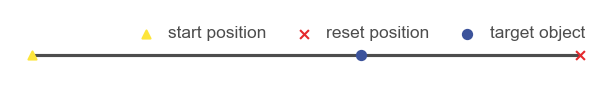

In [15]:
# Panel B
_, sub_ax = plt.subplots(figsize=(5, 0.7))
sub_ax = plot_fcts.plot_1D_reset_environment(Ag, minimalist=True, title="", sub_ax=sub_ax)
leg = sub_ax.get_legend()
for text in leg.get_texts():
    text_str = text.get_text()
    add_str = "object" if text_str == "target" else "position"
    text.set_text(f"{text_str} {add_str}") 
    text.set_fontsize("small")

ALL_FIGURES["1B"] = sub_ax

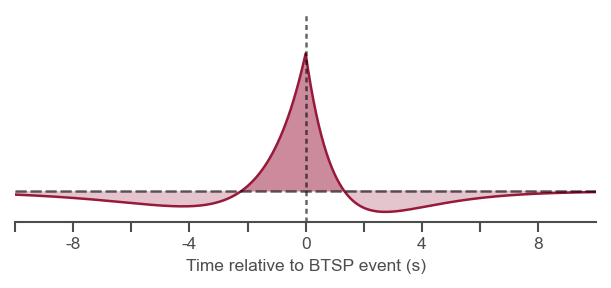

In [16]:
# Panel D
_, sub_ax = plt.subplots(figsize=(5, 1.8))
BTSP_param_dict = params_util.get_default_BTSP_filter_param_dict(incl_BTSP_str=False)
xlims = [-10, 10]

sub_ax = plot_util.plot_summed_exp_kernel(
    dt=Ag.dt, color=PCs.color, xlims=xlims, minimalist=True, lw=1.2, sub_ax=sub_ax, **BTSP_param_dict
)[0]

xticks = np.arange(*xlims, 2)
plot_util.set_alternating_ticks(sub_ax, xticks, round_dec=0)
plot_util.pad_axis(sub_ax, axis="y", pad_prop=0.25, prop_high=0.85)
sub_ax.set_xlabel("Time relative to BTSP event (s)")

ALL_FIGURES["1D"] = sub_ax

### Fig. 2

In [17]:
seed_all(SEED)
Pyrs = get_linear_Pyrs()
learner = run_linear(Pyrs, max_time_min=1.6)

 18%|███████                                | 579/3200 [00:00<00:04, 560.81it/s]

BTSP event recorded at step 513 (15.39 sec).


 40%|███████████████▏                      | 1276/3200 [00:02<00:03, 633.81it/s]

BTSP update applied at step 1207 (36.21 sec).


100%|██████████████████████████████████████| 3200/3200 [00:05<00:00, 613.85it/s]


Finishing last trajectory.


213it [00:00, 615.81it/s]

Only reached target 3 times (target: 10).
Trajectory lengths (4) to date: 25.60 +/- 16.00 sec each
Trajectory lengths (4) to date: 853.50 +/- 533.36 steps each
1 BTSP event triggered (allowed from steps 0 to 3413): occurred at step 513.


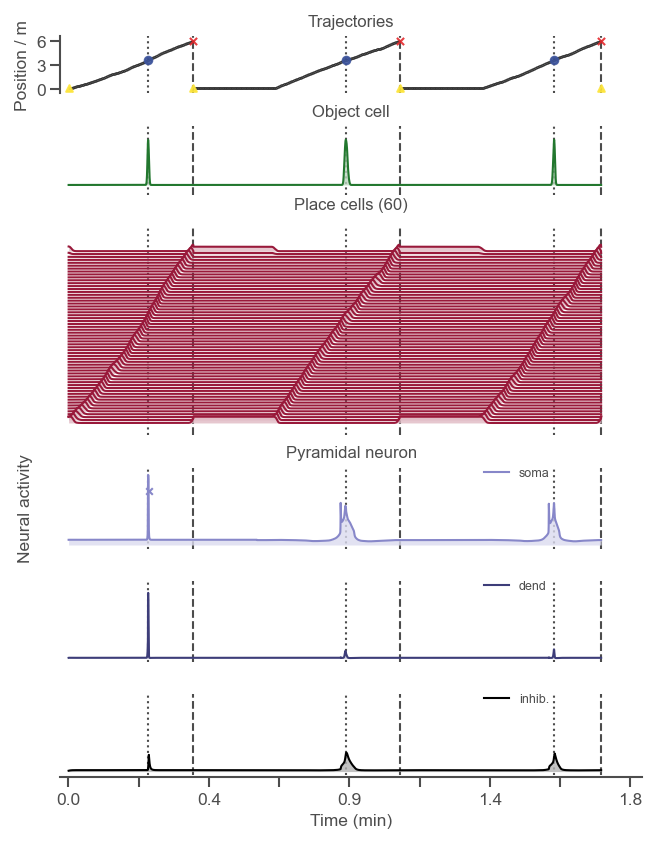

In [18]:
plot_kwargs = {
    "hspace": 0.34, 
    "height_ratios": [0.1, 0.12, 0.36, 0.14, 0.14, 0.14],
    "figsize": (5, 6.4)
}

Pyr_kwargs = {"norm_by": "shared_max", "separate_axes": True, "no_legend": True}

axes = plot_fcts.plot_1D_time_info(learner.Pyrs, Pyrs_spikes=False, Pyr_kwargs=Pyr_kwargs, **plot_kwargs)
axes[0, 0].set_yticks([0, 3, 6])
plot_util.expand_ticks(axes[-1, 0], axis="x", num_ticks=9, alternating=True, round_dec=1)
plot_util.pad_axis(axes[0, 0], axis="x", pad_prop=0.02, prop_high=1.0)

titles = ["Trajectories", "Object cell", f"Place cells ({PCs.n})", "Pyramidal neuron", "", ""]
for i, title in enumerate(titles):
    axes[i, 0].set_title(title, y=1.06)
    if i == 3:
        axes[i, 0].set_ylabel("Neural activity", labelpad=12)
    elif i > 0:
        axes[i, 0].set_ylabel("")

for i, comp in enumerate(["soma", "dend", "inhibit"]):
    Pyrs.add_compartment_legend(axes[3 + i, 0], compartment=comp, loc=(0.72, 0.8), frameon=False)
    axes[3 + i, 0].set_ylim(0.95, None)

ALL_FIGURES["2A"] = axes

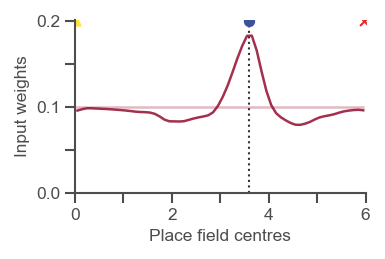

In [19]:
fig, sub_ax = plt.subplots(figsize=(2.5, 1.5))

plot_fcts.plot_recorded_1D_input_place_cell_weights(
    learner.get_recorded_weights()["weights"][:, 0],
    PCs.place_cell_centres,
    color=PCs.color,
    marker="none",
    plot_last_FWHM=False,
    sub_ax=sub_ax,
)

format_PF_xaxis(sub_ax)
plot_util.expand_ticks(sub_ax, axis="y", num_ticks=5, alternating=True, round_dec=1)

for position in ["start", "reset", "target"]:
    Pyrs.Agent.add_positions_spatially_to_plot(
        sub_ax, position_name=position, y_1D=0.2
    )
target_pos = Pyrs.Agent.get_position("target", dim_idx=0)
sub_ax.axvline(target_pos, ls="dotted", color="k", alpha=0.8, zorder=-5)

ALL_FIGURES["2B"] = sub_ax

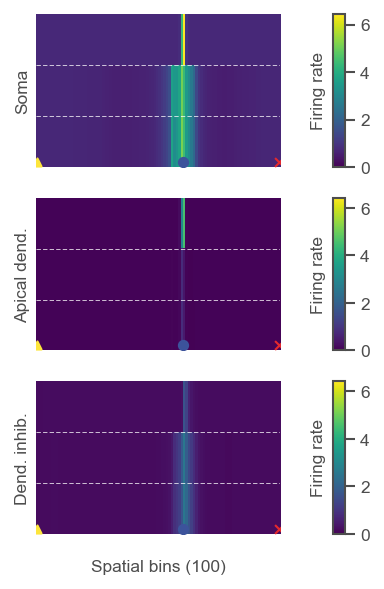

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(3, 4.5), squeeze=False)

num_bins = 100
Pyrs.plot_binned_rates(mark_runs=True, shared_range=True, plot_occ=False, axes=axes, num_bins=num_bins, vmin=0)
for sub_ax in axes.ravel():
    for position in ["start", "reset", "target"]:
        Pyrs.Agent.add_positions_spatially_to_plot(
            sub_ax, position_name=position, y_1D=2.4, pos_fact=100/6, pos_shift=-0.5
        )

labels = ["Soma", "Apical dend.", "Dend. inhib."]
for i, sub_ax in enumerate(axes.ravel()):
    sub_ax.set_title("")
    sub_ax.set_ylabel(labels[i])
sub_ax.set_xlabel(f"Spatial bins ({num_bins})", labelpad=12)

ALL_FIGURES["2C"] = axes

### Fig. 3
Takes about 2.5 min to rerun.

In [95]:
speed_data = run_linear_speeds()
regr = scipy.stats.linregress(speed_data["speed_means"], speed_data["widths"])

Loading data.


IndexError: index 0 is out of bounds for axis 0 with size 0

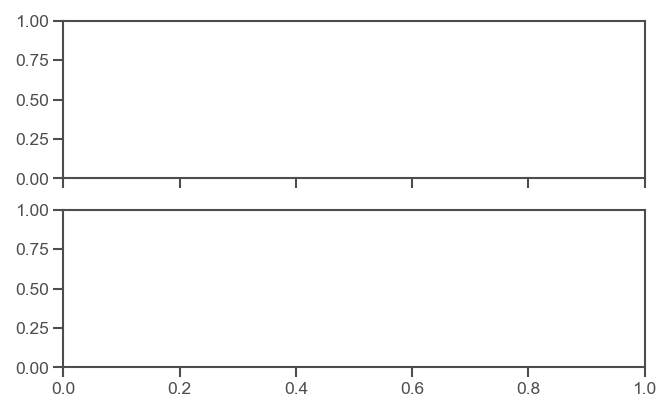

In [92]:
fig, ax1D = plt.subplots(2, 1, figsize=(5, 3), sharex=True, sharey=True)
for i, sub_ax in enumerate(ax1D):
    plot_fcts.plot_recorded_1D_input_place_cell_weights(
        speed_data["saved_weights"][i],
        PCs.place_cell_centres,
        color=PCs.color,
        marker="none",
        plot_last_FWHM=True,
        no_legend=True,
        sub_ax=sub_ax,
    )
    sub_ax.text(5, 0.223, f"{speed_data['saved_speeds'][i]} m/s", ha="center", fontsize="small")

    width = speed_data["widths"][np.where(speed_data["speed_means"] == speed_data["saved_speeds"][i])[0][0]]
    width = np.around(width, 2)
    rect = mpl_patches.Rectangle((4.68, 0.17), 0.64, 0.043, color=PCs.color, alpha=0.3, lw=0)
    sub_ax.add_patch(rect)
    sub_ax.text(5, 0.18, f"{width} m", ha="center", fontsize="small")

for sub_ax in ax1D:
    sub_ax.set_ylim([0, 0.28])
    sub_ax.set_yticks([0, 0.25])
    plot_util.expand_ticks(sub_ax, axis="y", num_ticks=6, alternating=True, round_dec=2)
    target_pos = Pyrs.Agent.get_position("target", dim_idx=0)
    sub_ax.axvline(target_pos, ls="dotted", color="k", alpha=0.8, zorder=-5)
    format_PF_xaxis(sub_ax)

ax1D[0].set_xlabel("")
for position in ["start", "reset", "target"]:
    Pyrs.Agent.add_positions_spatially_to_plot(
        ax1D[0], position_name=position, y_1D=0.27
    )

ALL_FIGURES["3A"] = ax1D

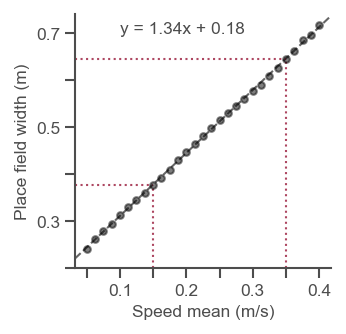

In [23]:
fig, sub_ax = plt.subplots(figsize=(2.2, 2.2))

sub_ax.scatter(speed_means, widths, s=10, alpha=0.5, color="k")

for axis in ["x", "y"]:
    plot_util.pad_axis(sub_ax=sub_ax, axis=axis)
sub_ax.spines[["top", "right"]].set_visible(False)
sub_ax.set_xlabel("Speed mean (m/s)")
sub_ax.set_xticks([0.05, 0.4])
plot_util.expand_ticks(sub_ax, axis="x", num_ticks=8, alternating=True, round_dec=2, start_idx=1)
sub_ax.set_ylabel("Place field width (m)")
sub_ax.set_yticks([0.2, 0.7])
plot_util.expand_ticks(sub_ax, axis="y", num_ticks=6, alternating=True, round_dec=1, start_idx=1)

x = np.asarray(sub_ax.get_xlim())
y = x * regr.slope + regr.intercept
sub_ax.plot(x, y, alpha=0.6, color="k", ls="dashed", zorder=-5)

regr_str = f"y = {regr.slope:.2f}x + {regr.intercept:.2f}"
sub_ax.text(0.1, 0.7, regr_str, fontsize="small")

xmin = sub_ax.get_xlim()[0]
ymin = sub_ax.get_ylim()[0]
for speed_mean in speeds_plot:
    width = widths[np.where(speed_means == speed_mean)[0][0]]
    # sub_ax.arrow(speed_mean, width - 0.07, 0, 0.03, head_width=0.01, head_length=0.02, color=PCs.color)
    sub_ax.plot([speed_mean] * 2, [ymin, width], color=PCs.color, ls="dotted", zorder=-5, alpha=0.8)
    sub_ax.plot([xmin, speed_mean], [width] * 2, color=PCs.color, ls="dotted", zorder=-5, alpha=0.8)

ALL_FIGURES["3B"] = sub_ax

### Fig. 4
Takes about 5 min to rerun.

In [79]:
shift_data = run_linear_shifts()

100%|███████████████████████████████████████████| 61/61 [04:59<00:00,  4.91s/it]


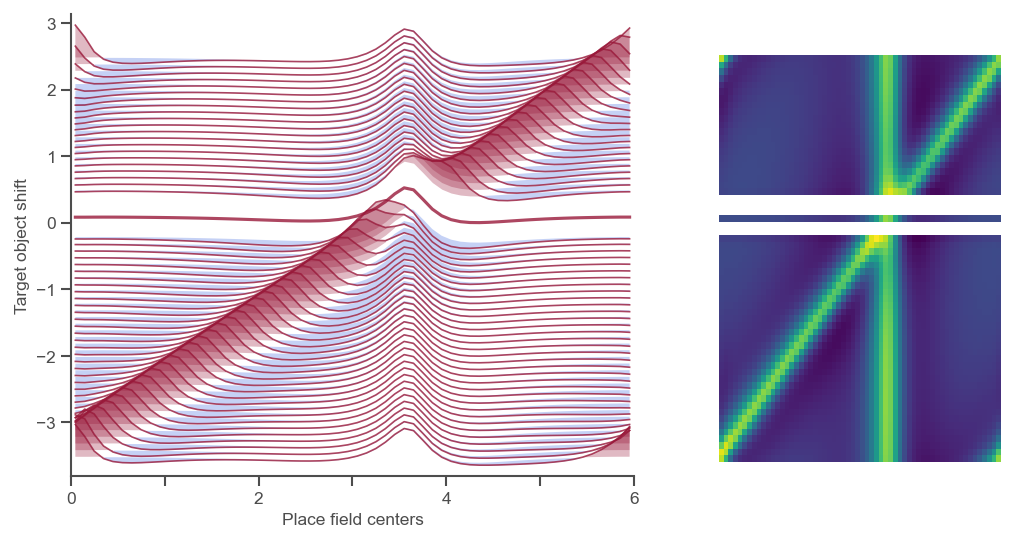

In [80]:
plot_relative = True

def plot_weights(sub_ax, PCs, weights, shift=0, scale=4, alpha=0.8, lw=1, relative=None):
    PC_centers = PCs.place_cell_centres[:, 0]
    plot_weights = weights * scale + shift
    if relative is not None:
        base = relative * scale + shift
        diff = plot_weights - base
        change_idxs = np.where(np.diff(diff >= 0))[0]
        for i, color in enumerate([PCs.color, "royalblue"]):
            cond = diff >= 0 if i == 0 else diff < 0
            for change_idx in change_idxs:
                if cond[change_idx] and np.abs(diff[change_idx]) >= np.abs(diff[change_idx + 1]):
                    cond[change_idx + 1] = cond[change_idx]
                elif cond[change_idx + 1] and np.abs(diff[change_idx]) < np.abs(diff[change_idx + 1]):
                    cond[change_idx] = cond[change_idx + 1]
            sub_ax.fill_between(PC_centers, base, plot_weights, color=color, alpha=0.3, lw=0, where=cond)
    sub_ax.plot(PC_centers, plot_weights, color=PCs.color, alpha=alpha, lw=lw)

fig, ax1D = plt.subplots(1, 2, figsize=(8, 5), width_ratios=[2, 1])
ax1D[0].spines[["top", "right"]].set_visible(False)

base_shift = shift_data["weights"][0][1].min()
plot_weights(ax1D[0], PCs, shift_data["weights"][0][1] - base_shift, lw=1.5)

relative = shift_data["weights"][0][1] - base_shift if plot_relative else None
for i, shift in enumerate(shifts):
    if len(shift_data["weights"][i]) == 3:
        plot_weights(ax1D[0], PCs, shift_data["weights"][i][-1] - base_shift, shift=shift, relative=relative, lw=0.8)

format_PF_xaxis(ax1D[0])

ax1D[0].set_xlabel("Place field centers")
ax1D[0].set_ylabel("Target object shift")

data = np.full((len(shift_data["weights"]), PCs.n), np.nan)
for i, shift in enumerate(shift_data["shifts"]):
    if shift == 0 or len(shift_data["weights"][i]) == 3:
        data[i] = shift_data["weights"][i][-1]
data = np.asarray(data[::-1])
ax1D[1].axis("off")
ax1D[1].imshow(data, interpolation="none", aspect="auto", cmap="viridis")

# adjust axes to match nicely
high_adj = shift_data["shifts"].max() + np.diff(shift_data["shifts"]).mean()
low_add = shift_data["shifts"].min() - ax1D[0].get_ylim()[0]
high_add = ax1D[0].get_ylim()[1] - high_adj

pad_prop = (low_add + high_add) / (high_adj - shift_data["shifts"].min())
prop_high = high_add / (low_add + high_add)
plot_util.pad_axis(ax1D[1], axis="y", pad_prop=pad_prop, prop_high=prop_high)

for sub_ax in ax1D:
    plot_util.pad_axis(sub_ax, axis="y", pad_prop=0.05)

### Fig. 5

### Save figures

In [55]:
SAVE = True

In [89]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)

Saving 7 figures...
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_08/1B_1652.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_08/1D_1652.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_08/2A_1652.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_08/2B_1652.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_08/2C_1652.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_08/3A_1652.png  & .svg
Figure saved to /home/cgillon/Documents/predhpc/scripts/figures/paper/25_07_08/3B_1652.png  & .svg
